# Notebook 05 — Test Set Evaluation + Per-Center Breakdown

**Run after Notebook 03.**

Evaluates the best checkpoint of each model on held-out test set.
Uses Test-Time Augmentation (horizontal flip) for segmentation.
Reports per-center DSC and AUC to demonstrate domain generalisation.

In [1]:
import sys, json
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import torch
from torch.cuda.amp import autocast
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('.').resolve().parent
paths        = json.loads((PROJECT_ROOT / 'paths.json').read_text())

FED7_ROOT    = Path(paths['fed7_root'])
PREPROCESSED = Path(paths['preprocessed'])
SPLITS_DIR   = PROJECT_ROOT / 'splits'
EXPERIMENTS  = Path(paths['experiments'])
MEDSAM_CKPT  = paths['medsam_ckpt']
FIGURES      = PROJECT_ROOT / 'figures'
FIGURES.mkdir(exist_ok=True)

for p in [str(PROJECT_ROOT), str(FED7_ROOT)]:
    if p not in sys.path: sys.path.insert(0, p)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

test_df = pd.read_csv(SPLITS_DIR / 'test.csv')
print(f'Test patients : {test_df["patient_id"].nunique()}')
print(f'Test slices   : {len(test_df)}')

Test patients : 42
Test slices   : 521


In [2]:
# ─────────────────────────────────────────────
# CELL 2 — TTA inference function
# ─────────────────────────────────────────────
from datasets.fedbca_dataset import FedBCaDataset, build_dataloader
from utils.metrics import dice_score
from sklearn.metrics import roc_auc_score

@torch.no_grad()
def evaluate_test(
    model, test_df, preprocessed_root,
    model_type='cnn', batch_size=4,
    use_tta=True, use_amp=True, device=DEVICE
):
    """
    Evaluate on test set with optional TTA (horizontal flip).
    Returns per-slice and per-patient metrics with per-center breakdown.
    """
    model.eval()

    ds = FedBCaDataset(
        test_df, str(preprocessed_root),
        mode='val', model_type=model_type,
        use_augmentation=False,
    )
    loader = build_dataloader(ds, batch_size, use_sampler=False)

    all_dsc      = []
    tumor_dsc    = []
    pid_probs    = defaultdict(list)
    pid_labels   = {}
    pid_center   = {}
    slice_records = []

    for batch in loader:
        imgs      = batch['image'].to(device, non_blocking=True)
        masks     = batch['mask'].to(device, non_blocking=True)
        labels    = batch['label']
        has_tumor = batch['has_tumor'].cpu().numpy()
        pids      = batch['patient_id']
        centers   = batch['center'].cpu().numpy()

        with autocast(enabled=use_amp):
            out_orig = model(imgs)
            seg_orig = torch.sigmoid(out_orig['seg'])
            cls_orig = torch.softmax(out_orig['cls'], dim=1)[:, 1]

            if use_tta:
                imgs_flip = torch.flip(imgs, dims=[-1])
                out_flip  = model(imgs_flip)
                seg_flip  = torch.flip(torch.sigmoid(out_flip['seg']), dims=[-1])
                cls_flip  = torch.softmax(out_flip['cls'], dim=1)[:, 1]
                seg_prob  = 0.5 * (seg_orig + seg_flip)
                cls_prob  = 0.5 * (cls_orig + cls_flip)
            else:
                seg_prob = seg_orig
                cls_prob = cls_orig

        seg_logit = torch.log(seg_prob.clamp(1e-7) / (1 - seg_prob).clamp(1e-7))

        for i in range(imgs.size(0)):
            if masks[i].sum() > 0:
                d = dice_score(seg_logit[i:i+1], masks[i:i+1])
                all_dsc.append(d)
                if has_tumor[i]:
                    tumor_dsc.append(d)

            pid = pids[i]
            pid_probs[pid].append(float(cls_prob[i].cpu().item()))
            pid_labels[pid] = int(labels[i].item())
            pid_center[pid] = int(centers[i])

    # Patient-level aggregation
    pt_ids   = sorted(pid_probs.keys())
    pt_prob  = np.array([float(np.mean(pid_probs[p])) for p in pt_ids])
    pt_label = np.array([pid_labels[p] for p in pt_ids])

    try:
        auc_overall = roc_auc_score(pt_label, pt_prob)
    except Exception:
        auc_overall = 0.5

    # Per-center breakdown
    per_center = {}
    for c in sorted(set(pid_center.values())):
        c_pids   = [p for p in pt_ids if pid_center[p] == c]
        c_prob   = np.array([float(np.mean(pid_probs[p])) for p in c_pids])
        c_label  = np.array([pid_labels[p] for p in c_pids])
        try:
            c_auc = roc_auc_score(c_label, c_prob) if len(np.unique(c_label)) >= 2 else 0.5
        except Exception:
            c_auc = 0.5
        per_center[c] = {'auc': c_auc, 'n': len(c_pids)}

    return {
        'tumour_dsc':  float(np.mean(tumor_dsc)) if tumor_dsc else 0.0,
        'dsc':         float(np.mean(all_dsc))   if all_dsc   else 0.0,
        'auc':         float(auc_overall),
        'combined':    0.55 * (float(np.mean(tumor_dsc)) if tumor_dsc else 0.0)
                      + 0.45 * float(auc_overall),
        'per_center':  per_center,
        'n_patients':  len(pt_ids),
    }

print('evaluate_test() defined.')

evaluate_test() defined.


In [3]:
# ─────────────────────────────────────────────
# CELL 3 — Evaluate best model per architecture
# (exp03, exp06, exp09 = Full Aug versions)
# ─────────────────────────────────────────────
import yaml
from models.efficientnet.model import EfficientNetMultiTask
from models.resnet50.model     import ResNet50MultiTask
from models.medsam.model       import MedSAMMultiTask

EVAL_EXPS = [
    ('exp03_eff_fullaug',    'EfficientNet-B0 Full Aug',  'cnn',  True,  None),
    ('exp06_res50_fullaug',  'ResNet50 Full Aug',          'cnn',  False, None),
    ('exp09_medsam_fullaug', 'MedSAM ViT-B Full Aug',     'cnn',  True,  None),
]

test_results = {}

for exp_name, label, mtype, amp, _ in EVAL_EXPS:
    ckpt_path = EXPERIMENTS / exp_name / 'checkpoint_best.pt'
    if not ckpt_path.exists():
        print(f'[skip] {exp_name} not found')
        continue

    print(f'\nEvaluating {label}...')
    ckpt   = torch.load(str(ckpt_path), map_location=DEVICE)
    config = ckpt.get('config', {})

    if 'eff' in exp_name:
        model = EfficientNetMultiTask(pretrained=False)
    elif 'res50' in exp_name:
        model = ResNet50MultiTask(pretrained=False)
    elif 'medsam' in exp_name:
        model = MedSAMMultiTask(
            medsam_checkpoint=MEDSAM_CKPT,
            freeze_encoder=False,
        )

    model.load_state_dict(ckpt['state'], strict=False)
    model = model.to(DEVICE)

    metrics = evaluate_test(
        model, test_df, PREPROCESSED,
        model_type=mtype,
        batch_size=config.get('batch_size', 4),
        use_tta=True,
        use_amp=amp,
        device=DEVICE,
    )

    test_results[label] = metrics

    print(f'  Tumour DSC : {metrics["tumour_dsc"]:.4f}')
    print(f'  AUC        : {metrics["auc"]:.4f}')
    print(f'  Combined   : {metrics["combined"]:.4f}')
    print(f'  Per-center AUC:')
    for c, cv in metrics['per_center'].items():
        print(f'    Center {c}: AUC={cv["auc"]:.4f} (n={cv["n"]})')

    del model
    torch.cuda.empty_cache()


Evaluating EfficientNet-B0 Full Aug...


C:\Users\Mayank\AppData\Local\Temp\ipykernel_1336460\3137916373.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt   = torch.load(str(ckpt_path), map_location=DEVICE)

[EfficientNet-B0-CORRECTED] in_ch=5 | params=4,169,692


C:\Users\Mayank\AppData\Local\Temp\ipykernel_1336460\1315938058.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


  Tumour DSC : 0.7544
  AUC        : 0.8123
  Combined   : 0.7805
  Per-center AUC:
    Center 1: AUC=0.6889 (n=23)
    Center 2: AUC=1.0000 (n=9)
    Center 3: AUC=1.0000 (n=4)
    Center 4: AUC=0.5556 (n=6)

Evaluating ResNet50 Full Aug...


...

  Tumour DSC : 0.7604
  AUC        : 0.8519
  Combined   : 0.8016
  Per-center AUC:
    Center 1: AUC=0.7333 (n=23)
    Center 2: AUC=0.9500 (n=9)
    Center 3: AUC=1.0000 (n=4)
    Center 4: AUC=0.7778 (n=6)

Evaluating MedSAM ViT-B Full Aug...


C:\Users\Mayank\AppData\Local\Temp\ipykernel_1336460\3137916373.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt   = torch.load(str(ckpt_path), map_location=DEVICE)

[MedSAM] resized pos_embed -> torch.Size([1, 16, 16, 768])
[MedSAM-MultiTask] in_ch=5 | freeze_enc=False | params=88,483,004


C:\Users\Mayank\AppData\Local\Temp\ipykernel_1336460\1315938058.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


  Tumour DSC : 0.6801
  AUC        : 0.8494
  Combined   : 0.7563
  Per-center AUC:
    Center 1: AUC=0.7222 (n=23)
    Center 2: AUC=1.0000 (n=9)
    Center 3: AUC=1.0000 (n=4)
    Center 4: AUC=0.5556 (n=6)


In [4]:
# ─────────────────────────────────────────────
# CELL 4 — Final summary table (test set)
# ─────────────────────────────────────────────
BENCHMARK = {'dsc': 0.841, 'auc': 0.866}

print('='*70)
print('  FINAL TEST SET RESULTS (TTA + tumor-centered crop)')
print('='*70)
hdr = f'{"Model":<30} {"DSC":>8} {"AUC":>8} {"Combined":>10} {"≥DSC":>6} {"≥AUC":>6}'
print(hdr)
print('-'*70)

for label, m in test_results.items():
    bd = '✓' if m['tumour_dsc'] >= BENCHMARK['dsc'] else '✗'
    ba = '✓' if m['auc']        >= BENCHMARK['auc'] else '✗'
    print(f"{label:<30} {m['tumour_dsc']:>8.4f} {m['auc']:>8.4f} "
          f"{m['combined']:>10.4f} {bd:>6} {ba:>6}")

print('-'*70)
print(f"{'FedBCa Centralized (baseline)':<30} "
      f"{BENCHMARK['dsc']:>8.4f} {BENCHMARK['auc']:>8.4f} "
      f"{0.55*BENCHMARK['dsc']+0.45*BENCHMARK['auc']:>10.4f} {'ref':>6} {'ref':>6}")
print('='*70)

# Save
pd.DataFrame([
    {'model': k, 'dsc': v['tumour_dsc'], 'auc': v['auc'], 'combined': v['combined']}
    for k, v in test_results.items()
]).to_csv(FIGURES / 'test_results.csv', index=False)
print('\nSaved: figures/test_results.csv')

  FINAL TEST SET RESULTS (TTA + tumor-centered crop)
Model                               DSC      AUC   Combined   ≥DSC   ≥AUC
----------------------------------------------------------------------
EfficientNet-B0 Full Aug         0.7544   0.8123     0.7805      ✗      ✗
ResNet50 Full Aug                0.7604   0.8519     0.8016      ✗      ✗
MedSAM ViT-B Full Aug            0.6801   0.8494     0.7563      ✗      ✗
----------------------------------------------------------------------
FedBCa Centralized (baseline)    0.8410   0.8660     0.8522    ref    ref

Saved: figures/test_results.csv


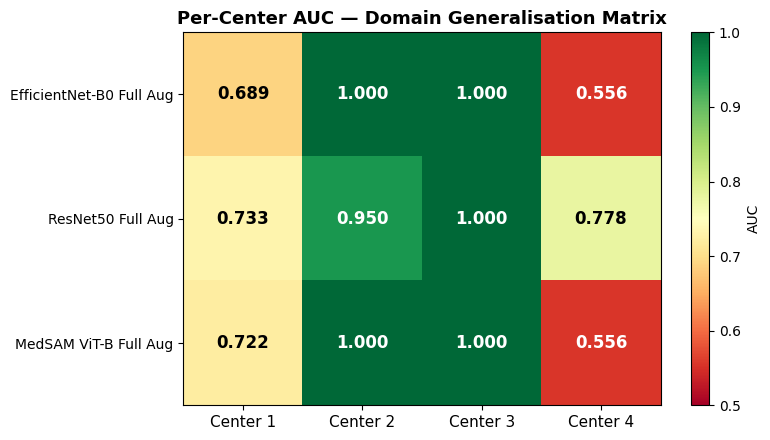

Saved: figures/per_center_auc_heatmap.png


In [5]:
# ─────────────────────────────────────────────
# CELL 5 — Per-center AUC heatmap
# ─────────────────────────────────────────────
models_with_centers = [
    (k, v) for k, v in test_results.items() if v.get('per_center')
]

if models_with_centers:
    all_centers = sorted(set(
        c for _, m in models_with_centers
        for c in m['per_center'].keys()
    ))
    model_names = [k for k, _ in models_with_centers]

    matrix = np.zeros((len(model_names), len(all_centers)))
    for i, (name, m) in enumerate(models_with_centers):
        for j, c in enumerate(all_centers):
            matrix[i, j] = m['per_center'].get(c, {}).get('auc', 0.0)

    fig, ax = plt.subplots(figsize=(len(all_centers)*2, len(model_names)*1.5))
    im = ax.imshow(matrix, cmap='RdYlGn', vmin=0.5, vmax=1.0, aspect='auto')

    ax.set_xticks(range(len(all_centers)))
    ax.set_xticklabels([f'Center {c}' for c in all_centers], fontsize=11)
    ax.set_yticks(range(len(model_names)))
    ax.set_yticklabels(model_names, fontsize=10)

    for i in range(len(model_names)):
        for j in range(len(all_centers)):
            v = matrix[i, j]
            ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                   fontsize=12, fontweight='bold',
                   color='black' if 0.6 <= v <= 0.85 else 'white')

    plt.colorbar(im, ax=ax, label='AUC')
    ax.set_title('Per-Center AUC — Domain Generalisation Matrix', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES / 'per_center_auc_heatmap.png', dpi=180, bbox_inches='tight')
    plt.show()
    print('Saved: figures/per_center_auc_heatmap.png')